# 04_deep_learning_forecasting.ipynb

## 分析の流れ

1. このノートブックの目的
2. 前処理済みデータの読み込み
3. train / validation / test の確認
4. Darts用のTimeSeries変換
5. LSTMモデルの実装
6. 必要ならN-BEATSまたはTCNモデルの実装
7. MAE / RMSE / MAPEによる評価
8. 既存モデルとの比較表
9. 予測値と実測値の可視化
10. 考察

## ライブラリの読み込み

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
# Dartsで生成される通知を減らす
import warnings
import logging
warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

# 数値計算のライブラリ
import numpy as np
import pandas as pd

# グラフを描画するためのライブラリ
from matplotlib import pyplot as plt

# Darts関連
from darts import TimeSeries
from darts.models import RNNModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mae, rmse, mape

## 1. このノートブックの目的

本ノートブックでは、UCI Individual Household Electric Power Consumption データを対象に、深層学習ベースの時系列予測モデルを実装する。

前処理、特徴量作成、従来の機械学習モデルによる予測は 03_machine_learning_forecasting.ipynb で実施済みである。本ノートブックでは、その特徴量データを用いて、Pythonの時系列分析ライブラリ Darts による LSTM モデルを構築し、時系列予測を行う。

予測結果については、実測値との比較、MAE・RMSE などの評価指標、既存の機械学習モデルとの比較を通じて評価する。これにより、深層学習モデルを時系列予測に適用した場合の有効性と課題を考察する。

## 2. 前処理済みデータの読み込み

In [2]:
file_path = "data/03_data/03_features_data.csv"

model_df = pd.read_csv(file_path)

model_df['datetime'] = pd.to_datetime(model_df['datetime'])
model_df = model_df.set_index('datetime')

print(f"{file_path}の読み込みが完了しました\n")
print(model_df.head(5))

data/03_data/03_features_data.csvの読み込みが完了しました

            Global_active_power     lag_1     lag_7    lag_14    lag_30  \
datetime                                                                  
2007-01-15             1.492137  2.090213  1.556500  1.909031  3.053475   
2007-01-16             1.171114  1.492137  1.297954  0.881414  2.354486   
2007-01-17             1.977561  1.171114  1.496389  0.704204  1.530435   
2007-01-18             1.264904  1.977561  1.566107  2.263481  1.157079   
2007-01-19             1.028083  1.264904  1.014789  1.884281  1.545658   

            rolling_mean_7  rolling_std_7  rolling_mean_14  rolling_std_14  \
datetime                                                                     
2007-01-15        1.605002       0.421003         1.544618        0.501632   
2007-01-16        1.595808       0.422937         1.514840        0.490588   
2007-01-17        1.577688       0.440191         1.535532        0.467376   
2007-01-18        1.646427       0.46

## 3. train / validation / test の確認

train      : 70%
validation : 15%
test       : 15%

In [3]:
n = len(model_df)

train_end = int(n * 0.7)
valid_end = int(n * 0.85)

train = model_df.iloc[:train_end]
valid = model_df.iloc[train_end : valid_end]
test  = model_df.iloc[valid_end:]

print("訓練データ   :", train.index.min(), "~", train.index.max())
print("検証データ   :", valid.index.min(), "~", valid.index.max())
print("テストデータ :", test.index.min(), "~", test.index.max())

訓練データ   : 2007-01-15 00:00:00 ~ 2009-09-28 00:00:00
検証データ   : 2009-09-29 00:00:00 ~ 2010-04-28 00:00:00
テストデータ : 2010-04-29 00:00:00 ~ 2010-11-26 00:00:00


## 4. Darts用のTimeSeries変換

In [4]:
# Global_active_powerを目的変数として扱う
target_col = "Global_active_power"

# Darts用に目的変数だけを作る
train_series = TimeSeries.from_series(train[target_col])  # 訓練用データ
valid_series = TimeSeries.from_series(valid[target_col])  # チューニング用データ
test_series  = TimeSeries.from_series(test[target_col])   # テストデータ

# 標準化
scaler = Scaler()

train_scaled = scaler.fit_transform(train_series)
valid_scaled = scaler.transform(valid_series)
test_scaled  = scaler.transform(test_series)

## 5. LSTMモデルの実装

In [5]:
# パラメータの作成
params = {
    'input_chunk_length' : 30,
    'training_length'    : 37,
    'hidden_dim'         : 64,
    'n_rnn_layers'       : 2,
    'dropout'            : 0.2,
    'batch_size'         : 32,
    'n_epochs'           : 50,
    'random_state'       : 42,
    'optimizer_kwargs'   : {"lr": 1e-3}
}

# LSTMモデル
model_lstm = RNNModel(model='LSTM', **params)

# 学習
model_lstm.fit(
    train_scaled,
    verbose=False
)

print("学習が完了しました")

学習が完了しました


In [6]:
# 予測
valid_pred_scaled = model_lstm.predict(n=len(valid_scaled))
valid_pred        = scaler.inverse_transform(valid_pred_scaled)
print("予測が完了しました\n")

# DataFrame化
valid_pred_df = valid_pred.to_dataframe()
valid_pred_df = valid_pred_df.rename(columns={"Global_active_power": "pred"})

# 予測値の表示
print(valid_pred_df.head(3))

Predicting DataLoader 0: 100%|███████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 17.54it/s]
予測が完了しました

                pred
datetime            
2009-09-29  0.951024
2009-09-30  1.002697
2009-10-01  0.982452


## 7. モデルの評価

In [7]:
valid_mae = mae(valid_series, valid_pred)
valid_rmse = rmse(valid_series, valid_pred)
valid_mape = mape(valid_series, valid_pred)

# DataFrame にまとめる
model_pred_val    = [{'モデル名':'LSTM', 'データ':'validation', 'MAE':valid_mae, 'RMSE':valid_rmse, 'MAPE': valid_mape}]
model_pred_val_df = pd.DataFrame(model_pred_val)

print("Validation 評価結果")
model_pred_val_df

Validation 評価結果


,モデル名,データ,MAE,RMSE,MAPE
0,LSTM,validation,0.554695,0.640241,40.911639


単に目的変数にデータを当てはめても、予測精度はそんなに良くないので、ラグ特徴量を組み込む、ハイパーパラメータチューニングを行う

## 8. ハイパーパラメータチューニング

In [8]:
from darts import TimeSeries

def params_grid_search(
    model_name: str,
    params_grid: dict,
    train_series: TimeSeries,
    valid_series: TimeSeries,
    verif: bool = True
):
    """
    指定された Darts の RNNModel に対して、ハイパーパラメータ候補を探索する。

    model_name の例:
        model_name = "LSTM"

    params_grid の例:
        params_grid = {
            "input_chunk_length": [14, 30],
            "hidden_dim"        : [32, 64],
            "n_rnn_layers"      : [1, 2],
            "dropout"           : [0.0, 0.2],
            "batch_size"        : [16, 32, 64]
            "n_epochs"          : [30]
        }
    """

    # モジュールのインポート
    from itertools import product
    import pandas as pd

    from darts.models import RNNModel
    from darts.dataprocessing.transformers import Scaler
    from darts.metrics import mae, rmse, mape

    # 結果を格納するための入れ物
    results = []

    # 探索候補の組み合わせを作成
    params_combinations = list(product(
        params_grid["input_chunk_length"],
        params_grid["hidden_dim"],
        params_grid["n_rnn_layers"],
        params_grid["dropout"],
        params_grid["batch_size"],
        params_grid["n_epochs"]
    ))

    print(f"試行する組み合わせの総数: {len(params_combinations)}")

    # train と valid の標準化
    scaler = Scaler()
    train_scaled = scaler.fit_transform(train_series)
    valid_scaled = scaler.transform(valid_series)

    # for ループで最適なパラメータを探索
    for i, (
        input_chunk_length,
        hidden_dim,
        n_rnn_layers,
        dropout,
        batch_size,
        n_epochs
    ) in enumerate(params_combinations, start=1):

        if verif:
            print("=" * 60)
            print(f"{i}/{len(params_combinations)} 回目の学習")
            print(
                f"input_chunk_length={input_chunk_length}, "
                f"hidden_dim={hidden_dim}, "
                f"n_rnn_layers={n_rnn_layers}, "
                f"dropout={dropout}, "
                f"batch_size={batch_size}, "
                f"n_epochs={n_epochs}"
            )

        try:
            model = RNNModel(
                model=model_name,
                input_chunk_length=input_chunk_length,
                training_length=input_chunk_length + 7,
                hidden_dim=hidden_dim,
                n_rnn_layers=n_rnn_layers,
                dropout=dropout,
                batch_size=batch_size,
                n_epochs=n_epochs,
                random_state=42,
                optimizer_kwargs={"lr": 1e-3}
            )

            # train_scaled で学習
            model.fit(
                train_scaled,
                val_series=valid_scaled,
                verbose=False
            )

            # validation 区間を予測
            pred_scaled = model.predict(n=len(valid_scaled))

            # 逆標準化
            pred = scaler.inverse_transform(pred_scaled)

            # 評価
            val_mae = mae(valid_series, pred)
            val_rmse = rmse(valid_series, pred)
            val_mape = mape(valid_series, pred)

            results.append({
                "model"             : model_name,
                "input_chunk_length": input_chunk_length,
                "training_length"   : input_chunk_length + 7,
                "hidden_dim"        : hidden_dim,
                "n_rnn_layers"      : n_rnn_layers,
                "dropout"           : dropout,
                "batch_size"        : batch_size,
                "n_epochs"          : n_epochs,
                "MAE"               : val_mae,
                "RMSE"              : val_rmse,
                "MAPE"              : val_mape
            })

            if verif:
                print(f"MAE  : {val_mae:.4f}")
                print(f"RMSE : {val_rmse:.4f}")
                print(f"MAPE : {val_mape:.4f}")
                print(f"\n{i}/{len(params_combinations)} 回目の学習が完了しました")

        except Exception as e:
            print("学習中にエラーが発生しました:", e)

    # 結果を DataFrame 化
    results_df = pd.DataFrame(results)

    if len(results_df) == 0:
        print("すべての組み合わせでエラーが発生しました。")
        return results_df

    # MAE が小さい順に並べる
    results_df = results_df.sort_values("MAE").reset_index(drop=True)

    print("\nハイパーパラメータチューニングの結果")
    display(results_df)

    print("\n最良のパラメータ")
    display(results_df.head(1))

    return results_df

In [9]:
params_grid = {
    "input_chunk_length": [14, 30],
    "hidden_dim"        : [32, 64],
    "n_rnn_layers"      : [1, 2],
    "dropout"           : [0.0, 0.2],
    'batch_size'        : [16, 32],
    "n_epochs"          : [30]
}

results_df = params_grid_search(
    model_name="LSTM",
    params_grid=params_grid,
    train_series=train_series,
    valid_series=valid_series,
    verif=True
)

試行する組み合わせの総数: 32
1/32 回目の学習
input_chunk_length=14, hidden_dim=32, n_rnn_layers=1, dropout=0.0, batch_size=16, n_epochs=30
Predicting DataLoader 0: 100%|███████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 25.11it/s]
MAE  : 0.2352
RMSE : 0.3070
MAPE : 20.4148

1/32 回目の学習が完了しました
2/32 回目の学習
input_chunk_length=14, hidden_dim=32, n_rnn_layers=1, dropout=0.0, batch_size=32, n_epochs=30
Predicting DataLoader 0: 100%|███████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 27.14it/s]
MAE  : 0.2603
RMSE : 0.3403
MAPE : 20.7977

2/32 回目の学習が完了しました
3/32 回目の学習
input_chunk_length=14, hidden_dim=32, n_rnn_layers=1, dropout=0.2, batch_size=16, n_epochs=30
Predicting DataLoader 0: 100%|███████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 31.48it/s]
MAE  : 0.2352
RMSE : 0.3070
MAPE : 20.4148

3/32 回目の学習が完了しました
4/32 回目の学習
input_chunk_length=14, hidden_dim=32, n_rnn_layers=1, dropout=0.2, batch_size=32, n_epochs=30
Predicting DataLo

,model,input_chunk_length,training_length,hidden_dim,n_rnn_layers,dropout,batch_size,n_epochs,MAE,RMSE,MAPE
0,LSTM,30,37,64,2,0.0,32,30,0.232312,0.304515,20.590505
1,LSTM,30,37,32,1,0.0,16,30,0.233245,0.305551,20.468087
2,LSTM,30,37,32,1,0.2,16,30,0.233245,0.305551,20.468087
3,LSTM,30,37,32,2,0.0,32,30,0.233403,0.301800,21.139303
4,LSTM,30,37,32,2,0.2,32,30,0.234143,0.302788,21.245742
5,LSTM,30,37,64,1,0.0,32,30,0.234184,0.302296,21.309586
6,LSTM,30,37,64,1,0.2,32,30,0.234184,0.302296,21.309586
7,LSTM,14,21,32,1,0.0,16,30,0.235225,0.306966,20.414761
8,LSTM,14,21,32,1,0.2,16,30,0.235225,0.306966,20.414761
9,LSTM,30,37,32,2,0.0,16,30,0.235966,0.303280,21.819655



最良のパラメータ


,model,input_chunk_length,training_length,hidden_dim,n_rnn_layers,dropout,batch_size,n_epochs,MAE,RMSE,MAPE
0,LSTM,30,37,64,2,0.0,32,30,0.232312,0.304515,20.590505


In [10]:
new_raw = [{
    'モデル名': 'LSTM(チューニング)',
    'データ' : 'validation',
    'MAE'   : round(results_df['MAE'].iloc[0], 4),
    'RMSE'  : round(results_df['RMSE'].iloc[0], 4),
    'MAPE'  : round(results_df['MAPE'].iloc[0], 4)
}]

new_df = pd.DataFrame(new_raw)

model_pred_df = pd.concat([model_pred_val_df, new_df], ignore_index=True)

model_pred_df

,モデル名,データ,MAE,RMSE,MAPE
0,LSTM,validation,0.554695,0.640241,40.911639
1,LSTM(チューニング),validation,0.232300,0.304500,20.590500


### ハイパーパラメータチューニング後のテストデータでの比較

In [11]:
# 最良のパラメータ
best_params = results_df.iloc[0]

# train + validation を結合
train_valid_series = train_series.append(valid_series)

# 標準化
final_scaler = Scaler()
train_valid_scaled = final_scaler.fit_transform(train_valid_series)

# 最良パラメータモデルを再定義
model_lstm_v2 = RNNModel(
    model='LSTM',
    input_chunk_length = int(best_params["input_chunk_length"]),
    training_length    = int(best_params["training_length"]),
    hidden_dim         = int(best_params["hidden_dim"]),
    n_rnn_layers       = int(best_params["n_rnn_layers"]),
    dropout            = float(best_params["dropout"]),
    n_epochs           = int(best_params["n_epochs"]),
    batch_size         = int(best_params["batch_size"]),
    random_state       = 42,
    optimizer_kwargs   = {"lr":1e-3}
)

# train + validation で再学習
model_lstm_v2.fit(
    train_valid_scaled,
    verbose=False
)

# test 区間を予測
test_pred_scaled = model_lstm_v2.predict(n=len(test_scaled))
test_pred = final_scaler.inverse_transform(test_pred_scaled)

# test 評価
test_mae  = mae(test_series, test_pred)
test_rmse = rmse(test_series, test_pred)
test_mape = mape(test_series, test_pred)

print("Test 評価結果")
print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"MAPE : {test_mape:.4f}")

Predicting DataLoader 0: 100%|███████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 15.18it/s]
Test 評価結果
MAE  : 0.3948
RMSE : 0.4826
MAPE : 59.7301


In [12]:
# 結果をDataFrameにまとめる
model_test = [{"モデル名":"LSTM(チューニング)", 'データ':'test', 'MAE':round(test_mae, 4), 'RMSE':round(test_rmse, 4), 'MAPE':round(test_mape, 4)}]
model_test_df = pd.DataFrame(model_test)
model_test_df

,モデル名,データ,MAE,RMSE,MAPE
0,LSTM(チューニング),test,0.3948,0.4826,59.7301


## 9. 特徴量の追加

In [13]:
# 目的変数
target_col = "Global_active_power"

# future_covariates に使う特徴量
covariate_cols = [
    "dayofweek",
    "month",
    "is_weekend"
]

# 目的変数をTimeSeries化
train_target = TimeSeries.from_series(train[target_col])
valid_target = TimeSeries.from_series(valid[target_col])
test_target  = TimeSeries.from_series(test[target_col])

# 特徴量データをDataFrame化
train_cov  = TimeSeries.from_dataframe(train, value_cols=covariate_cols)
valid_cov  = TimeSeries.from_dataframe(valid, value_cols=covariate_cols)
test_cov   = TimeSeries.from_dataframe(test, value_cols=covariate_cols)

### 標準化

In [14]:
target_scaler = Scaler()
cov_scaler = Scaler()

train_target_scaled = target_scaler.fit_transform(train_target)
valid_target_scaled = target_scaler.transform(valid_target)
test_target_scaled  = target_scaler.transform(test_target)

train_cov_scaled = cov_scaler.fit_transform(train_cov)
valid_cov_scaled = cov_scaler.transform(valid_cov)
test_cov_scaled  = cov_scaler.transform(test_cov)

### モデルの学習
future_covariates は、予測したい期間でも値が分かっている特徴量でなければいけない

In [15]:
# パラメータの作成
params_cov = {
    "model"              : str(best_params["model"]),
    "input_chunk_length" : int(best_params["input_chunk_length"]),
    "training_length"    : int(best_params["training_length"]),
    "hidden_dim"         : int(best_params["hidden_dim"]),
    "n_rnn_layers"       : int(best_params["n_rnn_layers"]),
    "dropout"            : float(best_params["dropout"]),
    "batch_size"         : int(best_params["batch_size"]),
    "n_epochs"           : int(best_params["n_epochs"]),
    "random_state"       : 42,
    "optimizer_kwargs"   : {"lr": 1e-3}
}


# モデルの作成
model_lstm_cov = RNNModel(**params_cov)

# モデル学習
model_lstm_cov.fit(
    series=train_target_scaled,
    future_covariates=train_cov_scaled,
    val_series=valid_target_scaled,
    val_future_covariates=valid_cov_scaled,
    verbose=False
)

print("共変量ありLSTMの学習が完了しました")

共変量ありLSTMの学習が完了しました


In [16]:
train_valid_cov_scaled = train_cov_scaled.append(valid_cov_scaled)

valid_pred_scaled = model_lstm_cov.predict(
    n = len(valid_target_scaled),
    future_covariates = train_valid_cov_scaled
)

valid_pred = target_scaler.inverse_transform(valid_pred_scaled)

Predicting DataLoader 0: 100%|███████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 18.49it/s]


In [17]:
valid_mae_cov = mae(valid_target, valid_pred)
valid_rmse_cov = rmse(valid_target, valid_pred)
valid_mape_cov = mape(valid_target, valid_pred)

print("Validation 評価結果: LSTM + future_covariates")
print(f"MAE  : {valid_mae_cov:.4f}")
print(f"RMSE : {valid_rmse_cov:.4f}")
print(f"MAPE : {valid_mape_cov:.4f}")

Validation 評価結果: LSTM + future_covariates
MAE  : 0.2254
RMSE : 0.2981
MAPE : 21.0909


### 最終評価

In [18]:
train_valid_target = train_target.append(valid_target)
train_valid_cov = train_cov.append(valid_cov)

final_target_scaler = Scaler()
final_cov_scaler = Scaler()

train_valid_target_scaled = final_target_scaler.fit_transform(train_valid_target)
test_target_scaled = final_target_scaler.transform(test_target)

train_valid_cov_scaled = final_cov_scaler.fit_transform(train_valid_cov)
test_cov_scaled = final_cov_scaler.transform(test_cov)

all_cov_scaled = train_valid_cov_scaled.append(test_cov_scaled)

In [19]:
# モデルの学習
model_lstm_cov_final = RNNModel(**params_cov)

# 当てはめ
model_lstm_cov_final.fit(
    series=train_valid_target_scaled,
    future_covariates=train_valid_cov_scaled,
    verbose=False
)

# テストデータに対して予測を出す
test_pred_cov_scaled = model_lstm_cov_final.predict(
    n=len(test_target_scaled),
    future_covariates=all_cov_scaled
)

# 逆標準化
test_pred_cov = final_target_scaler.inverse_transform(test_pred_cov_scaled)

# 指標を出す
test_mae_cov  = mae(test_target, test_pred_cov)
test_rmse_cov = rmse(test_target, test_pred_cov)
test_mape_cov = mape(test_target, test_pred_cov)

print("Test 評価結果: LSTM + future_covariates")
print(f"MAE  : {test_mae_cov:.4f}")
print(f"RMSE : {test_rmse_cov:.4f}")
print(f"MAPE : {test_mape_cov:.4f}")

Predicting DataLoader 0: 100%|███████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 15.11it/s]
Test 評価結果: LSTM + future_covariates
MAE  : 0.1955
RMSE : 0.2537
MAPE : 25.3631


### 結果をDataFrameにまとめる

In [20]:
model_test_df = pd.DataFrame([
    {
        "モデル名": "LSTM(チューニング)",
        "データ": "test",
        "MAE" : test_mae,
        "RMSE": test_rmse,
        "MAPE": test_mape,
    },
    {
        "モデル名": "LSTM(特徴量あり)",
        "データ": "test",
        "MAE" : test_mae_cov,
        "RMSE": test_rmse_cov,
        "MAPE": test_mape_cov,
    }
])

display(model_test_df)

,モデル名,データ,MAE,RMSE,MAPE
0,LSTM(チューニング),test,0.394803,0.482642,59.730131
1,LSTM(特徴量あり),test,0.195529,0.253708,25.363071


## 10. 予測値と実測値の可視化

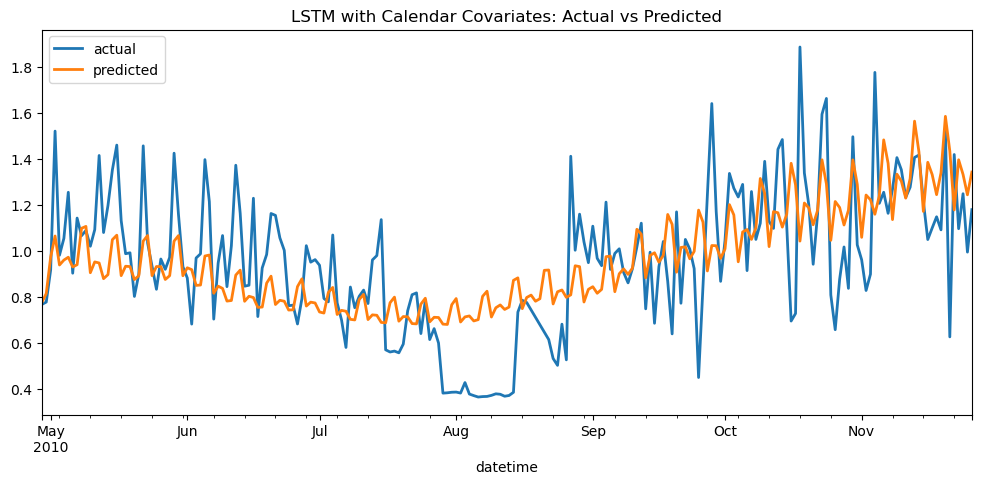

In [21]:
plt.figure(figsize=(12, 5))
test_target.plot(label="actual")
test_pred_cov.plot(label="predicted")
plt.title("LSTM with Calendar Covariates: Actual vs Predicted")
plt.legend()
plt.show()

## 11. 残差の確認

In [22]:
actual_df = test_target.to_dataframe()
pred_df   = test_pred_cov.to_dataframe()

residual_df = actual_df.copy()
residual_df["pred"] = pred_df.iloc[:, 0]
residual_df["residual"] = residual_df[target_col] - residual_df["pred"]

residual_df.head(3)

,Global_active_power,pred,residual
datetime,,,
2010-04-29,0.766475,0.774668,-0.008193
2010-04-30,0.776825,0.814158,-0.037333
2010-05-01,0.916776,0.972350,-0.055573


### 可視化

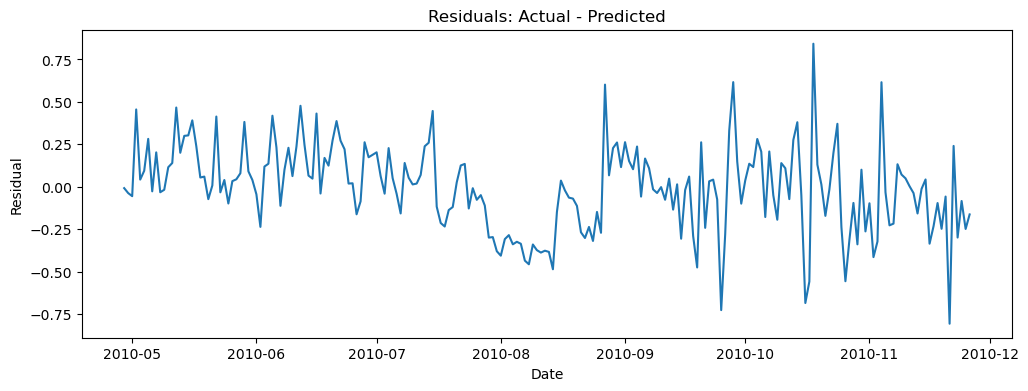

In [23]:
plt.figure(figsize=(12, 4))
plt.plot(residual_df.index, residual_df["residual"])
plt.title("Residuals: Actual - Predicted")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

## 12. 結果の保存

In [24]:
from pathlib import Path

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# 評価指標の保存
model_results_04 = [
    {
        "モデル名": "LSTM(チューニング + カレンダー特徴量)",
        "予測期間": f"{test.index.min()} ~ {test.index.max()}",
        "MAE": test_mae_cov,
        "RMSE": test_rmse_cov,
        "MAPE": test_mape_cov,
    }
]

model_results_04_df = pd.DataFrame(model_results_04)

model_results_04_df.to_csv(
    output_dir / "04_lstm_forecasting_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

# 予測値の保存
actual_df = test_target.to_dataframe()
pred_df = test_pred_cov.to_dataframe()

save_pred_df = actual_df.copy()
save_pred_df = save_pred_df.rename(columns={target_col: "y_true"})
save_pred_df["lstm_pred"] = pred_df.iloc[:, 0].values

save_pred_df.to_csv(
    output_dir / "04_lstm_forecasting_predictions.csv",
    index=True,
    encoding="utf-8-sig"
)

print("saved:")
print(output_dir / "04_lstm_forecasting_metrics.csv")
print(output_dir / "04_lstm_forecasting_predictions.csv")

saved:
outputs\04_lstm_forecasting_metrics.csv
outputs\04_lstm_forecasting_predictions.csv


## 13. 考察

本ノートブックでは、Dartsを用いてLSTMによる時系列予測を行った。

まず、目的変数のみを用いたLSTMモデルを構築し、validationデータで評価した。その後、ハイパーパラメータチューニングを行い、最良パラメータを用いてtrain + validationデータで再学習し、testデータで最終評価を行った。

さらに、dayofweek、month、is_weekendといったカレンダー特徴量をfuture_covariatesとして追加したLSTMモデルを構築した。その結果、特徴量なしのLSTMと比較して、MAE・RMSE・MAPEのすべてで改善が見られた。

特に、カレンダー特徴量は予測対象期間でも事前に分かる情報であるため、future_covariatesとして自然に利用できる。今回の結果から、電力消費量の予測において曜日や月、週末情報が一定の予測改善に寄与することが確認できた。

一方で、MAPEは依然として高めであり、消費電力量が小さい日の相対誤差が大きく影響している可能性がある。また、今回利用した特徴量はカレンダー情報に限定されているため、今後はラグ特徴量、移動平均、季節性特徴量、あるいはTDA由来の特徴量を加えることで、さらなる精度改善を検討できる。